# Recurrent Neural Networks
You should build an end-to-end machine learning pipeline using a recurrent neural network model. In particular, you should do the following:
- Load the `jena climate` dataset using [Pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). You can find this dataset in the [keras repository](https://keras.io/examples/timeseries/timeseries_weather_forecasting/).
- Split the dataset into training, validation, and test sets. Note that you cannot split time series using [Scikit-Learn](https://keras.io/examples/timeseries/timeseries_weather_forecasting/).
- Build an end-to-end machine learning pipeline, including a [recurrent neural network](https://keras.io/examples/timeseries/timeseries_weather_forecasting/) model.
- Optimize your pipeline by validating your design decisions.
- Test the best pipeline on the test set and report various [evaluation metrics](https://scikit-learn.org/0.15/modules/model_evaluation.html).  
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

In [2]:
!wget https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2025-06-03 09:01:14--  https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.139.207, 173.194.210.207, 173.194.212.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.139.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13568290 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  --.-KB/s    in 0.1s    

2025-06-03 09:01:14 (132 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13568290/13568290]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [5]:
df = pd.read_csv('jena_climate_2009_2016.csv')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [28]:
df_train = df[:int(0.8 * len(df))]
df_test = df[int(0.8 * len(df)):]

print(f"Dataset size: {df.shape}")
print(f"Training dataset size: {df_train.shape}")
print(f"Test dataset size: {df_test.shape}")

Dataset size: (420551, 15)
Training dataset size: (336440, 15)
Test dataset size: (84111, 15)


In [29]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336440 entries, 0 to 336439
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        336440 non-null  object 
 1   p (mbar)         336440 non-null  float64
 2   T (degC)         336440 non-null  float64
 3   Tpot (K)         336440 non-null  float64
 4   Tdew (degC)      336440 non-null  float64
 5   rh (%)           336440 non-null  float64
 6   VPmax (mbar)     336440 non-null  float64
 7   VPact (mbar)     336440 non-null  float64
 8   VPdef (mbar)     336440 non-null  float64
 9   sh (g/kg)        336440 non-null  float64
 10  H2OC (mmol/mol)  336440 non-null  float64
 11  rho (g/m**3)     336440 non-null  float64
 12  wv (m/s)         336440 non-null  float64
 13  max. wv (m/s)    336440 non-null  float64
 14  wd (deg)         336440 non-null  float64
dtypes: float64(14), object(1)
memory usage: 38.5+ MB


In [30]:
df_train.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000,336440.000000
mean,988.832741,8.987613,283.059741,4.550634,76.204815,13.170494,9.296727,3.873679,5.874406,9.404092,1217.704598,2.150055,3.557588,174.167379
std,8.349543,8.440685,8.517808,6.831052,16.499619,7.477666,4.150630,4.671460,2.634851,4.202040,40.129560,1.538542,2.333178,87.131402
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,0.000000,0.000000,0.000000
25%,983.810000,2.890000,277.000000,-0.120000,65.480000,7.520000,6.060000,0.820000,3.820000,6.120000,1189.130000,1.010000,1.800000,123.400000
50%,989.240000,8.970000,283.100000,4.740000,79.500000,11.470000,8.570000,2.090000,5.410000,8.670000,1214.810000,1.790000,3.000000,197.500000
75%,994.312500,15.070000,289.140000,9.740000,89.600000,17.160000,12.080000,5.110000,7.630000,12.210000,1244.640000,2.890000,4.770000,234.200000
max,1013.940000,35.860000,310.270000,23.110000,100.000000,59.020000,28.320000,42.120000,18.130000,28.820000,1393.540000,14.630000,23.500000,360.000000


array([[<Axes: title={'center': 'p (mbar)'}>,
        <Axes: title={'center': 'T (degC)'}>,
        <Axes: title={'center': 'Tpot (K)'}>,
        <Axes: title={'center': 'Tdew (degC)'}>],
       [<Axes: title={'center': 'rh (%)'}>,
        <Axes: title={'center': 'VPmax (mbar)'}>,
        <Axes: title={'center': 'VPact (mbar)'}>,
        <Axes: title={'center': 'VPdef (mbar)'}>],
       [<Axes: title={'center': 'sh (g/kg)'}>,
        <Axes: title={'center': 'H2OC (mmol/mol)'}>,
        <Axes: title={'center': 'rho (g/m**3)'}>,
        <Axes: title={'center': 'wv (m/s)'}>],
       [<Axes: title={'center': 'max. wv (m/s)'}>,
        <Axes: title={'center': 'wd (deg)'}>, <Axes: >, <Axes: >]],
      dtype=object)

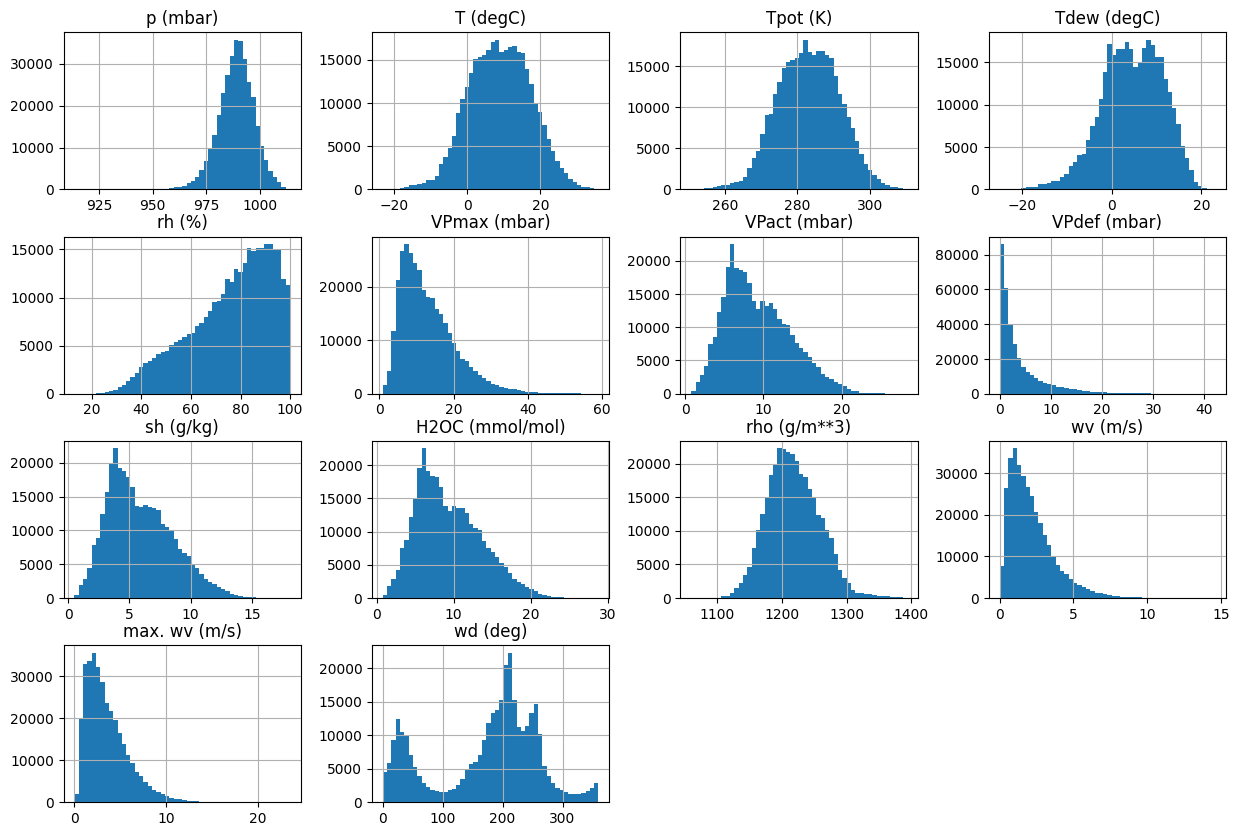

In [31]:
df_train.hist(figsize=(15, 10), bins=50)